In [1]:
import timeit as t
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
#### %matplotlib notebook
%matplotlib inline

# Setup styles for plotting
style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available if style != 'classic')
plt.style.use(style_list[10])
print(style_list)

['default', 'classic', 'Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
# 2.1 Function to find Nth Fibonacci term
def FibonacciRec(N:int):
    # Base Case
    if (N < 2):
        return N

    # Recursively computing the term
    # using recurrence relation
    return FibonacciRec(N - 1) + FibonacciRec(N - 2)

# Test fibonacci: compute results for N 1 .. 20



### 2.1 Merjenje časa izvajanja
Za pravilno meritev časa izvajanja bomo uporabljali funkcijo `timeit()`, namenjeno testiranju hitrosti manjših koščkov kode. Uporablja se na naslednji način, primer:
`t.timeit('quicksort(data)','from __main__ import data,quicksort', number = num)`

Prvi niz je ukaz, ki ga merimo, nato drugi niz definira importe oziroma knjižnice, nato pa še, kolikokrat želimo izvesti ta ukaz (večkrat je bolj zanesljiva meritev časa). 

In [3]:
# Measure execution time : 
fibNumber = 10

t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)

print('Fibonnaci for ', fibNumber, ' execution time sec: ', t_fib)

Fibonnaci for  10  execution time sec:  6.700021913275123e-06


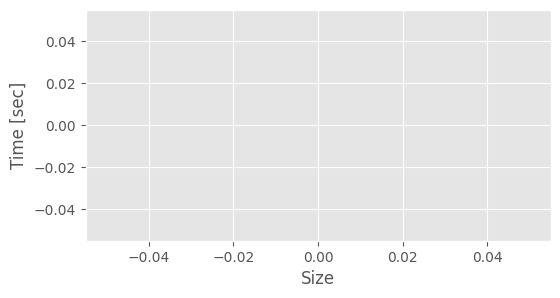

In [4]:
# 2.3 Plot graph of Fibonnaci execution time

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,3,5]
# zanka



ax = plt.figure(figsize=[6,3])
plt.plot(size,t_list)
plt.xlabel('Size')
plt.ylabel('Time [sec]')
plt.show()


In [5]:
# 2.4 Class for algorithm testing
from utils import Algorithm

# Testing
a = Algorithm()



In [6]:
# 2.5  Fibonnaci algoritem z uporabo Alogrithm
# Prva verzija, kjer je N dolocen s stevilom ponovitev

class FibonacciRecursion(Algorithm):
    def __init__(self):
        self.name = "FibonacciRecursion"

    # Function to find Nth Fibonacci term
    def FibonacciR(self, N:int):
        # Count each call of the function
        self.count_op += 1

        # Base Case
        if (N < 2):
            return N

        # Recursively computing the term
        # using recurrence relation
        return self.FibonacciR(N - 1) + self.FibonacciR(N - 2)

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.FibonacciR(N)

        return self.result_data


s = FibonacciRecursion()
s.data_params = {'N': 10}
print('Test result: ', s.run(10))


 >>  0 , msec: 0.014 , operations:  177
 >>  1 , msec: 0.015 , operations:  177
 >>  2 , msec: 0.013 , operations:  177
 >>  3 , msec: 0.011 , operations:  177
 >>  4 , msec: 0.011 , operations:  177
 >>  5 , msec: 0.011 , operations:  177
 >>  6 , msec: 0.011 , operations:  177
 >>  7 , msec: 0.011 , operations:  177
 >>  8 , msec: 0.011 , operations:  177
 >>  9 , msec: 0.011 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  0.0005262999911792576  Avg iter msec: 0.05262999911792576
Test result:  {'name': 'FibonacciRecursion', 'avg_msec': 0.05262999911792576, 'avg_O': 177.0, 'niter': 10, 'output': 55}


 >>  0 , msec: 0.002 , operations:  1
 >>>  FibonacciRecursion  > Total run() sec:  0.00017469999147579074  Avg iter msec: 0.17469999147579074
 >>  0 , msec: 0.002 , operations:  5
 >>>  FibonacciRecursion  > Total run() sec:  2.1499989088624716e-05  Avg iter msec: 0.021499989088624716
 >>  0 , msec: 0.002 , operations:  15
 >>>  FibonacciRecursion  > Total run() sec:  2.0000006770715117e-05  Avg iter msec: 0.020000006770715117
 >>  0 , msec: 0.011 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  2.7700007194653153e-05  Avg iter msec: 0.027700007194653153
 >>  0 , msec: 0.124 , operations:  1973
 >>>  FibonacciRecursion  > Total run() sec:  0.00014390001888386905  Avg iter msec: 0.14390001888386905
 >>  0 , msec: 1.362 , operations:  21891
 >>>  FibonacciRecursion  > Total run() sec:  0.0013865999935660511  Avg iter msec: 1.3865999935660511
 >>  0 , msec: 15.627 , operations:  242785
 >>>  FibonacciRecursion  > Total run() sec:  0.015671200002543628  Avg iter msec: 15.6

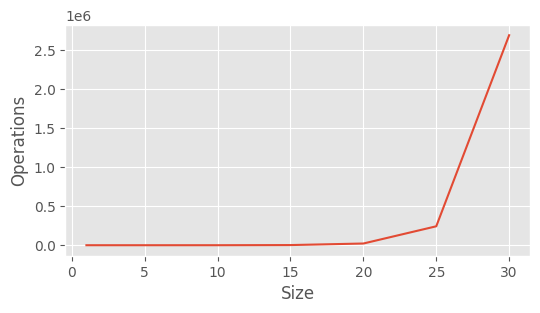

In [7]:
# 2.6 Testing Fibonacci recursion

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30]

s = FibonacciRecursion()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])



ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list)

plt.xlabel('Size')
plt.ylabel('Operations')

plt.show()

In [8]:
# 2.7 Fibonnaci algorithm optimized

class FibonacciOptimized(Algorithm):
    def __init__(self):
        self.name = "FibonacciOptimized"

    # Function to find Nth Fibonacci term
    def Fibonacci(self, N):
        f=[0]*(N + 2)
        # 0th and 1st number of the
        # series are 0 and 1
        f[0] = 0
        f[1] = 1
        # Iterate over the range [2, N]
        for i in range(2,N+1) :
            self.count_op += 1
            # Add the previous 2 numbers
            # in the series and store it
            f[i] = f[i - 1] + f[i - 2]
        # Return Nth Fibonacci Number
        return f[N]

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.Fibonacci(N)

        return self.result_data


s = FibonacciOptimized()
s.data_params = {'N': 10}
print(s.run(1))



 >>  0 , msec: 0.005 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  0.00018509998335503042  Avg iter msec: 0.18509998335503042
{'name': 'FibonacciOptimized', 'avg_msec': 0.18509998335503042, 'avg_O': 9.0, 'niter': 1, 'output': 55}


In [9]:
# 2.7 Testing Fibonacci optimized



### 3. Sortirni algoritmi

Testiramo in primerjamo delovanje različnih algoritmov sortiranja števil od najmanjšega do največjega. Pri tem imamo več scenarijev, glede na vhodne podatke:
* **optimalni**, v tem primeru so števila že urejena v želenem vrstnem redu
* **najslabši**, podatki so urejeni v obratnem vrstnem redu kot želimo
* **normalni**, podatki so urejeni naključno.


In [10]:
def insertionSort2(array):
    d = array.copy()
    for j in range(1, len(d)):
        key = d[j]
        i = j - 1
        while i >= 0 and d[i] > key:
            d[i + 1] = d[i]
            i = i - 1
        d[i + 1] = key
    return d

In [11]:
# Vrne set podatkov
def createSet(type = None, size = 100):
    if type == 1:  #return numbers sorted in ascening order -> best case
        return np.linspace(1,size,size).tolist() 
    elif type == 2: #return numbers in descending order -> wost case
        return np.linspace(size,1,size).tolist()
    else: #return a random assortment of numbers
        return (np.trunc(np.absolute(size*10/2.0 + size*10/5.0*np.random.randn(size)))/10).tolist()

In [12]:
# 3.1 Preskus parametrov type, size: izpiši dobljene podatke
print(createSet(1,20))


[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]


In [13]:
# 3.3 Preskus insertionSort2



In [14]:
class InsertionSort(Algorithm):
    def __init__(self):
        self.name = "Insertion Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()

    def insertionSort(self, array):
        d = array.copy()
        for j in range(1, len(d)):
            key = d[j]
            i = j - 1
            while i >= 0 and d[i] > key:
                self.count_op+=1
                d[i + 1] = d[i]
                i = i - 1
            d[i + 1] = key
        return d


    def run_once(self):
        self.result_data = self.insertionSort(self.input_data)
        return self.result_data

In [15]:
# 3.4 Testiraj InsertionSort razred

s = InsertionSort()
s.data_params = {'size': 1000, 'type': 2}

print(s.run(10))



 >>  0 , msec: 44.465 , operations:  499500
 >>  1 , msec: 41.682 , operations:  499500
 >>  2 , msec: 40.239 , operations:  499500
 >>  3 , msec: 42.097 , operations:  499500
 >>  4 , msec: 41.943 , operations:  499500
 >>  5 , msec: 42.066 , operations:  499500
 >>  6 , msec: 40.800 , operations:  499500
 >>  7 , msec: 40.540 , operations:  499500
 >>  8 , msec: 40.838 , operations:  499500
 >>  9 , msec: 42.879 , operations:  499500
 >>>  Insertion Sort  > Total run() sec:  0.4186477000184823  Avg iter msec: 41.86477000184823
{'name': 'Insertion Sort', 'avg_msec': 41.86477000184823, 'avg_O': 499500.0, 'niter': 10, 'output': [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 6

In [16]:
# 3.5 Kompleksnost Insertion sort

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000,3000]

s = InsertionSort()
s.data_params['type'] = 3

# Dodaj kodo za testiranje in izrisovanje grafa






In [17]:
# Opcija: uporaba tega razreda za izris
from utils import AlgorithmBenchmark


In [18]:
def quicksort(arr):
    """ Quicksort a list

    :type arr: list
    :param arr: List to sort
    :returns: list -- Sorted list
    """
    if len(arr) <= 1:
        return arr
    else:
        return quicksort([x for x in arr[1:] if x<arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x>=arr[0]])

In [19]:
class QuickSort(Algorithm):
    def __init__(self):
        self.name = "Quick Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()


    # Function to find the partition position
    def partition(self, array, low, high):
    
        # Choose the rightmost element as pivot
        pivot = array[high]
    
        # Pointer for greater element
        i = low - 1
    
        # Traverse through all elements
        # compare each element with pivot
        for j in range(low, high):
            if array[j] <= pivot:
    
                # If element smaller than pivot is found
                # swap it with the greater element pointed by i
                i = i + 1
    
                # Swapping element at i with element at j
                (array[i], array[j]) = (array[j], array[i])
                self.count_op+=1
    
        # Swap the pivot element with
        # the greater element specified by i
        (array[i + 1], array[high]) = (array[high], array[i + 1])
        self.count_op+=1
    
        # Return the position from where partition is done
        return i + 1
 
 
    # Function to perform quicksort
    def quicksort(self, array, low, high):
        if low < high:
    
            # Find pivot element such that
            # element smaller than pivot are on the left
            # element greater than pivot are on the right
            pi = self.partition(array, low, high)
    
            # Recursive call on the left of pivot
            self.quicksort(array, low, pi - 1)
    
            # Recursive call on the right of pivot
            self.quicksort(array, pi + 1, high)


    def run_once(self):
        N = len(self.input_data)
        self.result_data = self.quicksort(self.input_data, 0, N-1)
        return self.result_data

In [20]:
# 3.6 Kompleksnost Quick sort : dodaj kodo, izvedi testiranja





In [21]:
# 3.7 Opcijsko: Kompleksnost Buble sort : dodaj kodo, izvedi testiranja